In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.datasets import fetch_openml

In [18]:
glass = pd.read_excel('glass.xlsx', sheet_name='glass')
glass_data = glass.drop('Type', axis=1)   # features
glass_target = glass['Type']              # target

In [19]:
glass_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
dtypes: float64(9)
memory usage: 15.2 KB


In [20]:
# glass_data.fillna(0, inplace=True)  # Replace NaNs with 0  
glass_data.dropna(inplace=True)  # Drop rows with NaNs

In [21]:
glass_data['Type'] = glass_target.astype(int)  # Ensure the target is integer

###  Exploratory Data Analysis (EDA)

In [22]:
# Display basic info
print("Dataset Info:")
print(glass_data.info())

# Check for missing values
print("\nMissing Values:")
print(glass_data.isnull().sum())

# Descriptive statistics
print("\nDescriptive Statistics:")
print(glass_data.describe())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None

Missing Values:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

Descriptive Statistics:
               RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.4970

### Data Visualization

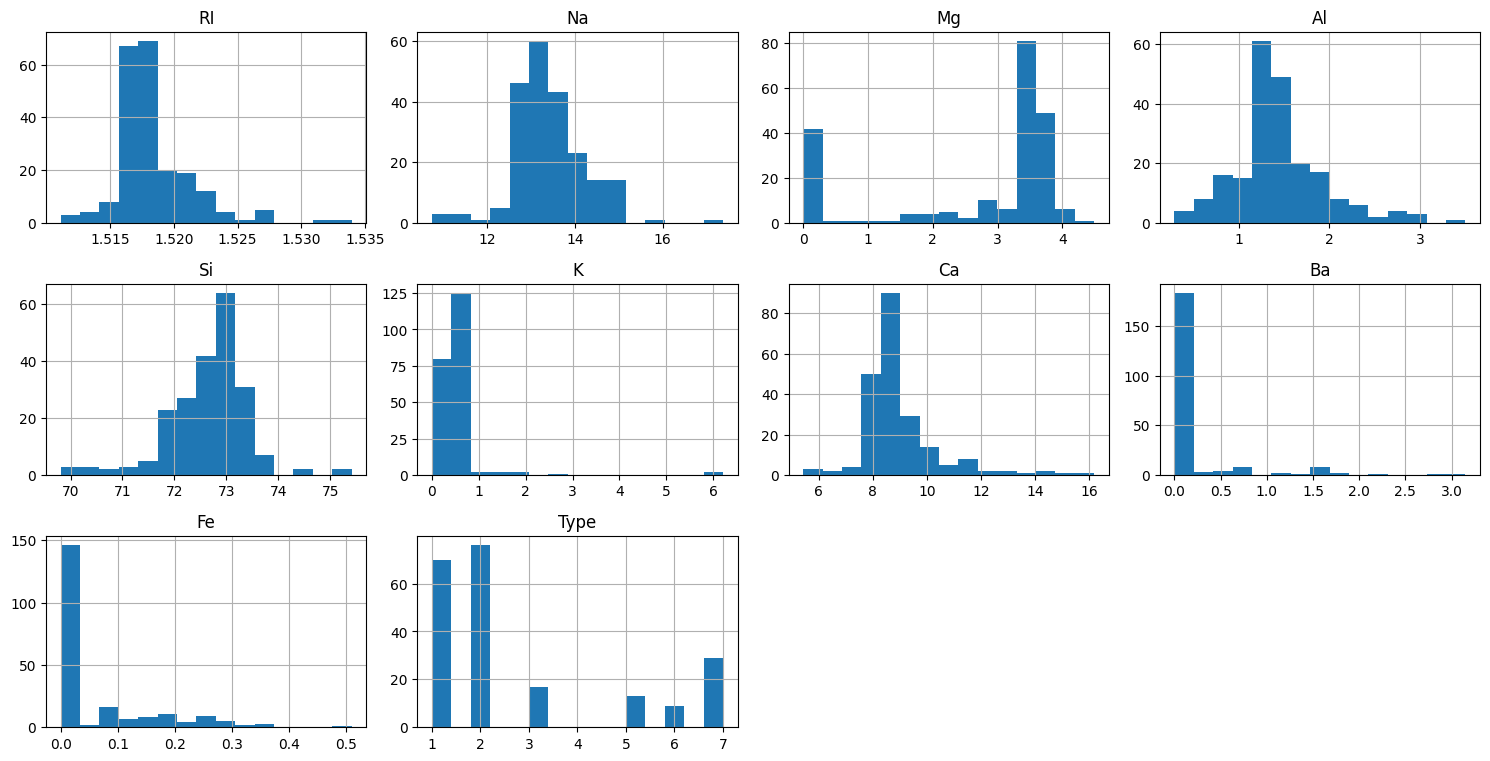

In [24]:
# Histogram for feature distributions
glass_data.hist(bins=15, figsize=(15, 10), layout=(4, 4))
plt.tight_layout()
plt.show()

In [25]:
glass_data

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


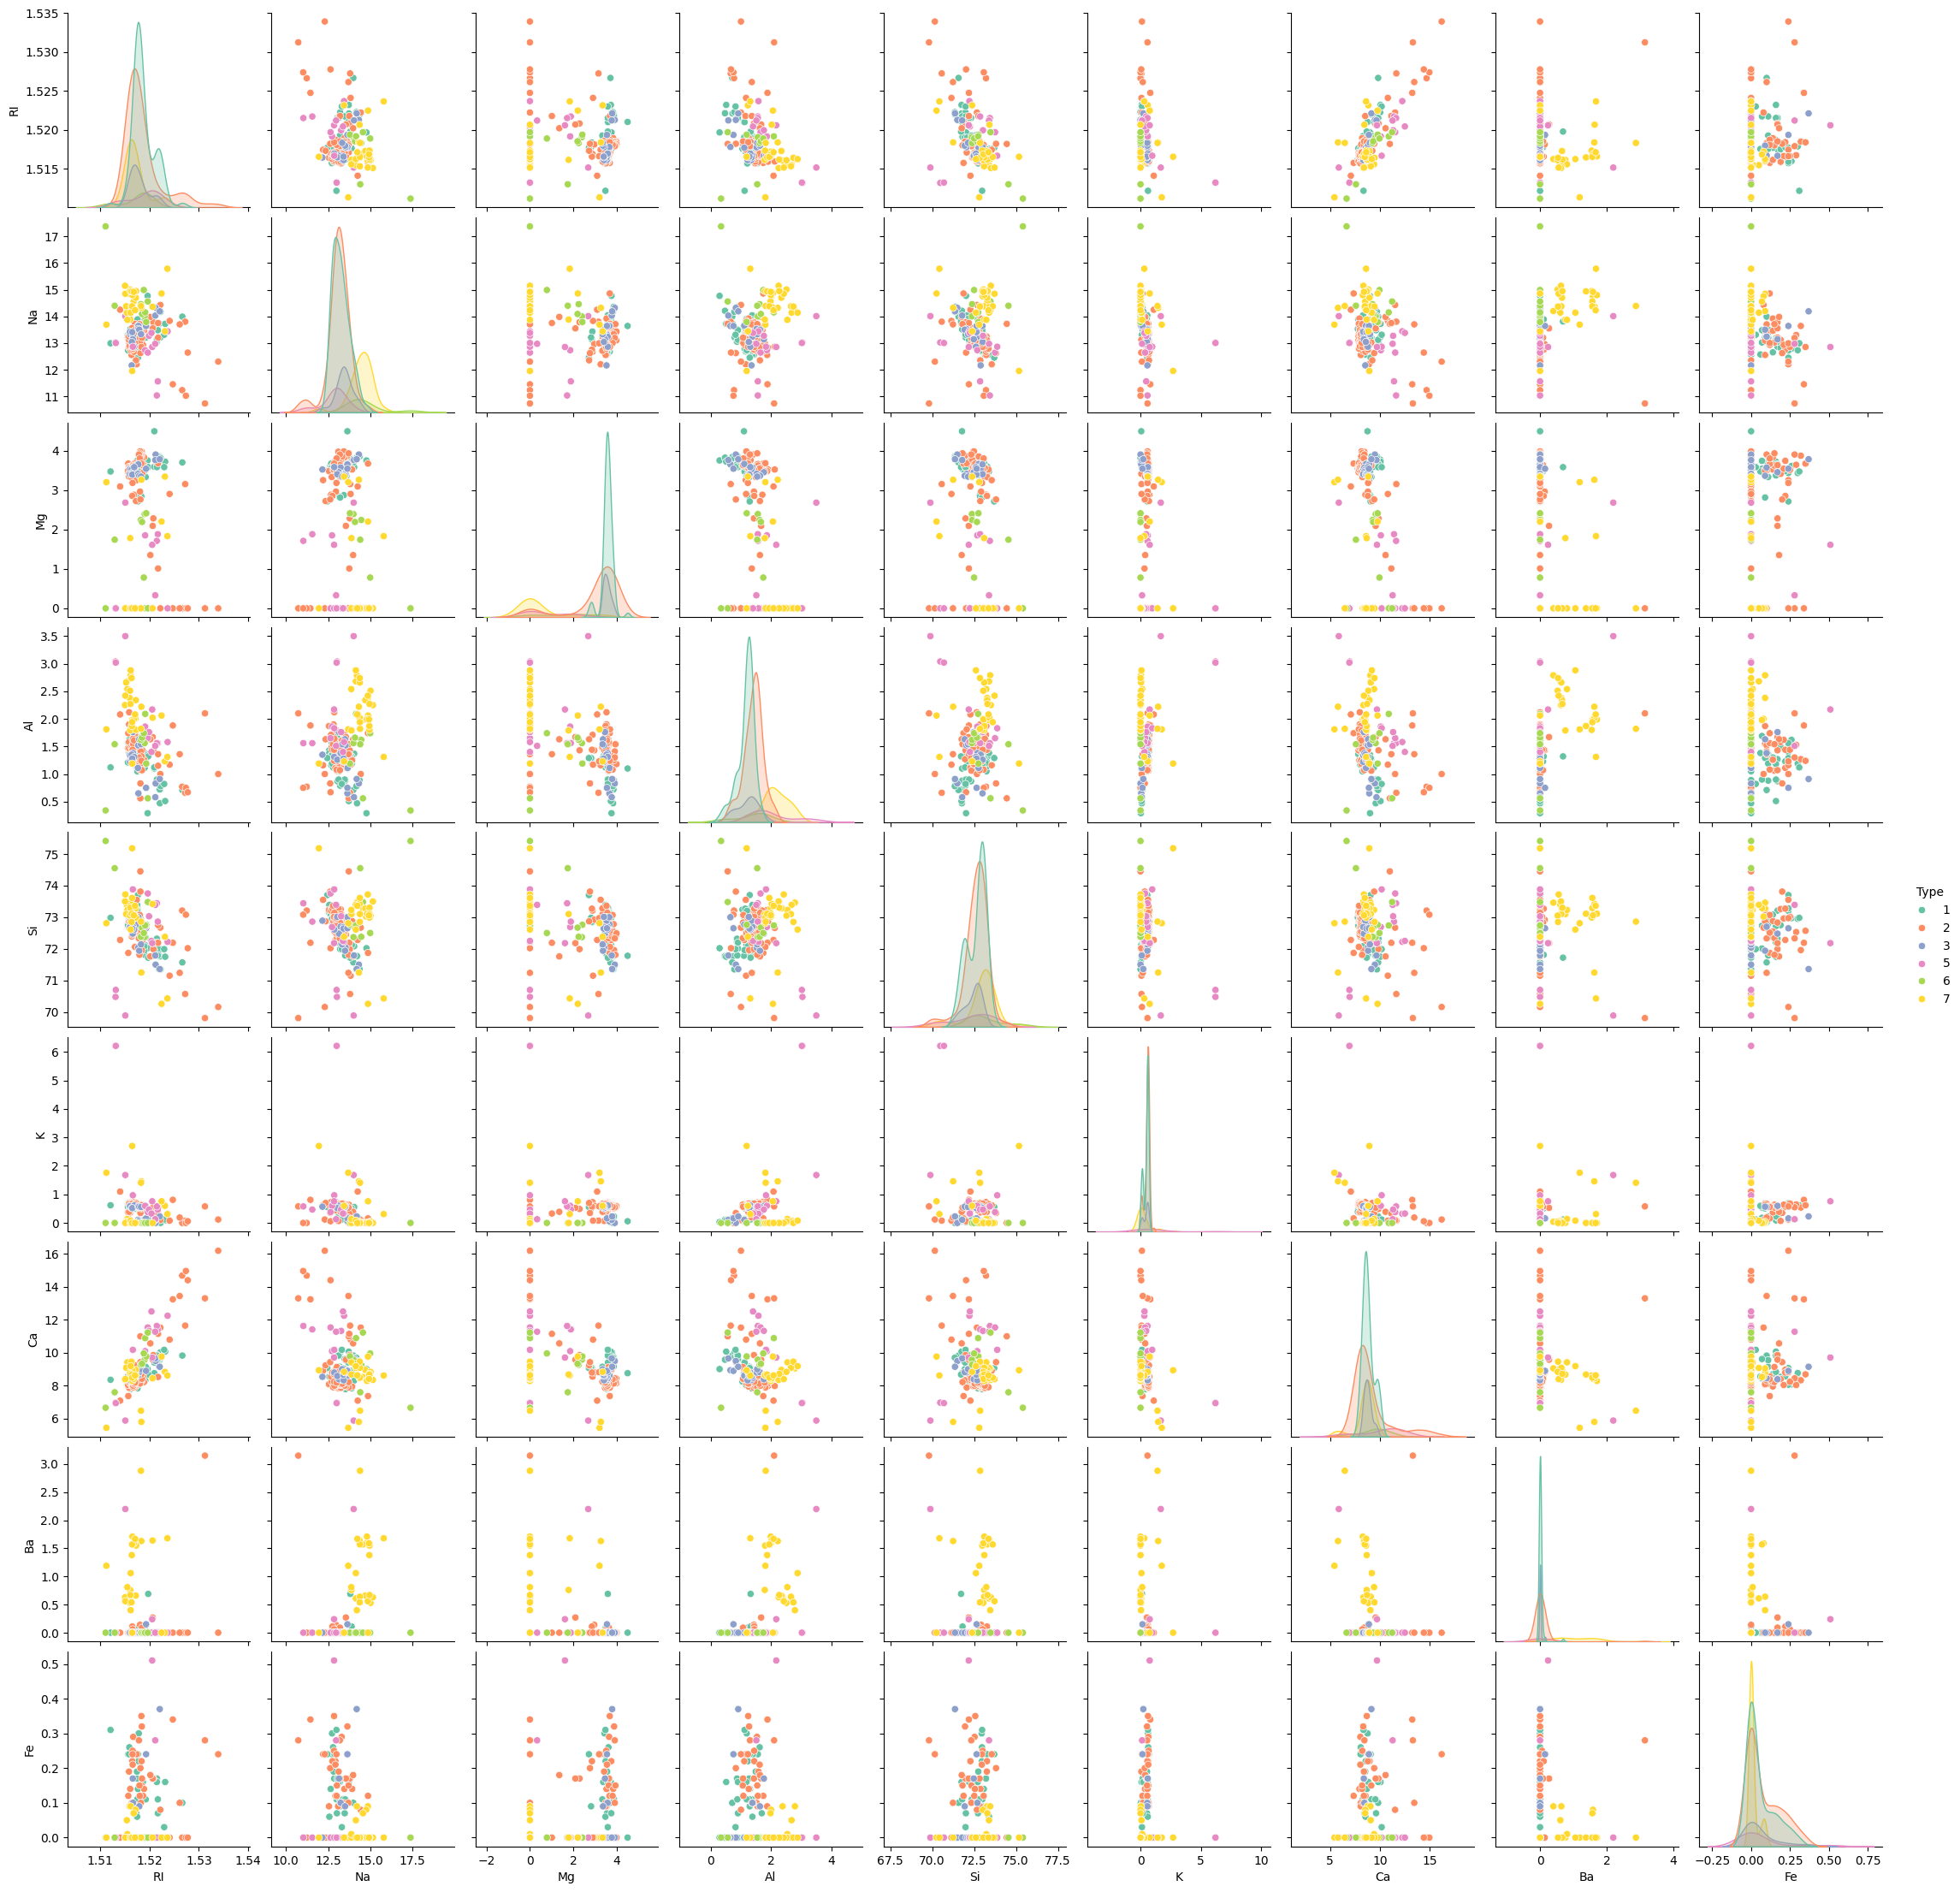

In [26]:
# Pairplot for feature relationships
sns.pairplot(glass_data, hue='Type', palette='Set2', diag_kind='kde')
plt.show()

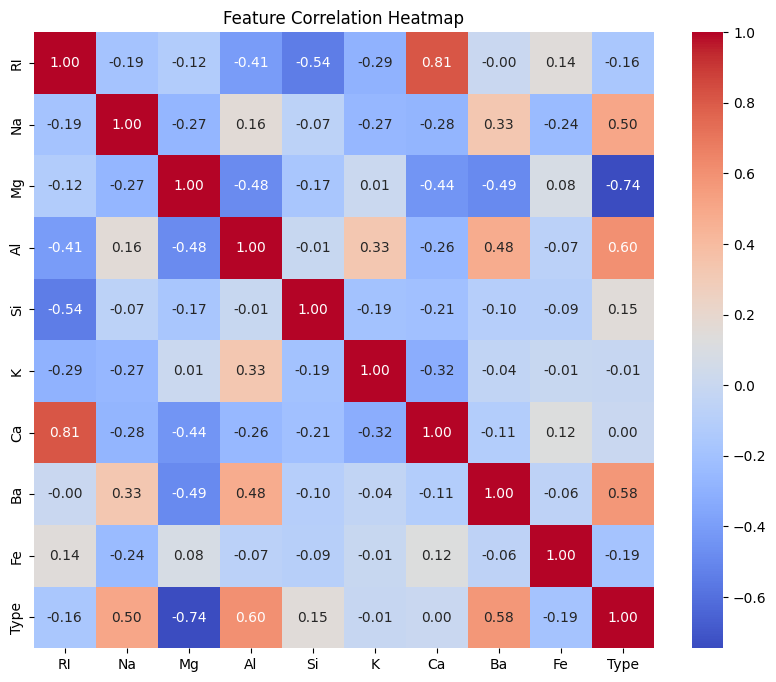

In [27]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(glass_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

### Data Preprocessing

In [31]:
# Check for missing values
if glass_data.isnull().sum().sum() > 0:
    imputer = SimpleImputer(strategy='mean')
    glass_data.iloc[:, :-1] = imputer.fit_transform(glass_data.iloc[:, :-1])

# Standardize the features
scaler = StandardScaler()
features = glass_data.iloc[:, :-1]
target = glass_data['Type']
features_scaled = scaler.fit_transform(features)

### Random Forest Model Implementation


In [32]:
# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(features_scaled, target, test_size=0.3, random_state=42, stratify=target)

# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate the model
y_pred_rf = rf_model.predict(X_test)
print("\nRandom Forest Model Performance:")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))



Random Forest Model Performance:
[[20  1  0  0  0  0]
 [ 2 18  0  2  1  0]
 [ 3  0  2  0  0  0]
 [ 0  1  0  3  0  0]
 [ 0  0  0  0  3  0]
 [ 0  1  0  0  0  8]]
              precision    recall  f1-score   support

           1       0.80      0.95      0.87        21
           2       0.86      0.78      0.82        23
           3       1.00      0.40      0.57         5
           5       0.60      0.75      0.67         4
           6       0.75      1.00      0.86         3
           7       1.00      0.89      0.94         9

    accuracy                           0.83        65
   macro avg       0.83      0.80      0.79        65
weighted avg       0.85      0.83      0.83        65



### Bagging and Boosting Methods

In [35]:
# Bagging Classifier
bagging_model = BaggingClassifier(estimator=RandomForestClassifier(), n_estimators=50, random_state=42)
bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)
print("\nBagging Model Performance:")
print(confusion_matrix(y_test, y_pred_bagging))
print(classification_report(y_test, y_pred_bagging))

# Gradient Boosting Classifier
boosting_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
boosting_model.fit(X_train, y_train)
y_pred_boosting = boosting_model.predict(X_test)
print("\nBoosting Model Performance:")
print(confusion_matrix(y_test, y_pred_boosting))
print(classification_report(y_test, y_pred_boosting))

# ===============================
# Compare Model Performances
# ===============================

# Accuracy Comparison
rf_acc = accuracy_score(y_test, y_pred_rf)
bagging_acc = accuracy_score(y_test, y_pred_bagging)
boosting_acc = accuracy_score(y_test, y_pred_boosting)

print("\nModel Accuracy Comparison:")
print(f"Random Forest Accuracy: {rf_acc:.2f}")
print(f"Bagging Accuracy: {bagging_acc:.2f}")
print(f"Boosting Accuracy: {boosting_acc:.2f}")



Bagging Model Performance:
[[20  1  0  0  0  0]
 [ 3 17  0  2  1  0]
 [ 3  0  2  0  0  0]
 [ 0  3  0  1  0  0]
 [ 0  0  0  0  3  0]
 [ 0  1  0  0  0  8]]
              precision    recall  f1-score   support

           1       0.77      0.95      0.85        21
           2       0.77      0.74      0.76        23
           3       1.00      0.40      0.57         5
           5       0.33      0.25      0.29         4
           6       0.75      1.00      0.86         3
           7       1.00      0.89      0.94         9

    accuracy                           0.78        65
   macro avg       0.77      0.71      0.71        65
weighted avg       0.79      0.78      0.77        65


Boosting Model Performance:
[[18  1  0  0  1  1]
 [ 1 20  0  1  1  0]
 [ 2  0  2  0  1  0]
 [ 0  1  0  1  0  2]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  9]]
              precision    recall  f1-score   support

           1       0.86      0.86      0.86        21
           2       0.91      0.87    

# Explanation of Each Step

## EDA:
* Basic structure of the dataset (info, describe).
* Checking for missing values and outliers.
* Understanding relationships and distributions using visualizations.

## Data Visualization:
* Histograms, pair plots, and a correlation heatmap.
* Data Preprocessing:
* Imputation for missing values (if any).
* Standardization of features for uniform scaling.

## Random Forest Model:
* Train-test split.
* Model training and evaluation using confusion matrix and classification report.

## Bagging and Boosting:
* Bagging model using BaggingClassifier.
* Boosting model using GradientBoostingClassifier.
* Comparison of accuracies and evaluation metrics.

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None

Summary Statistics:
               RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150   10.730000    0.000000    0.

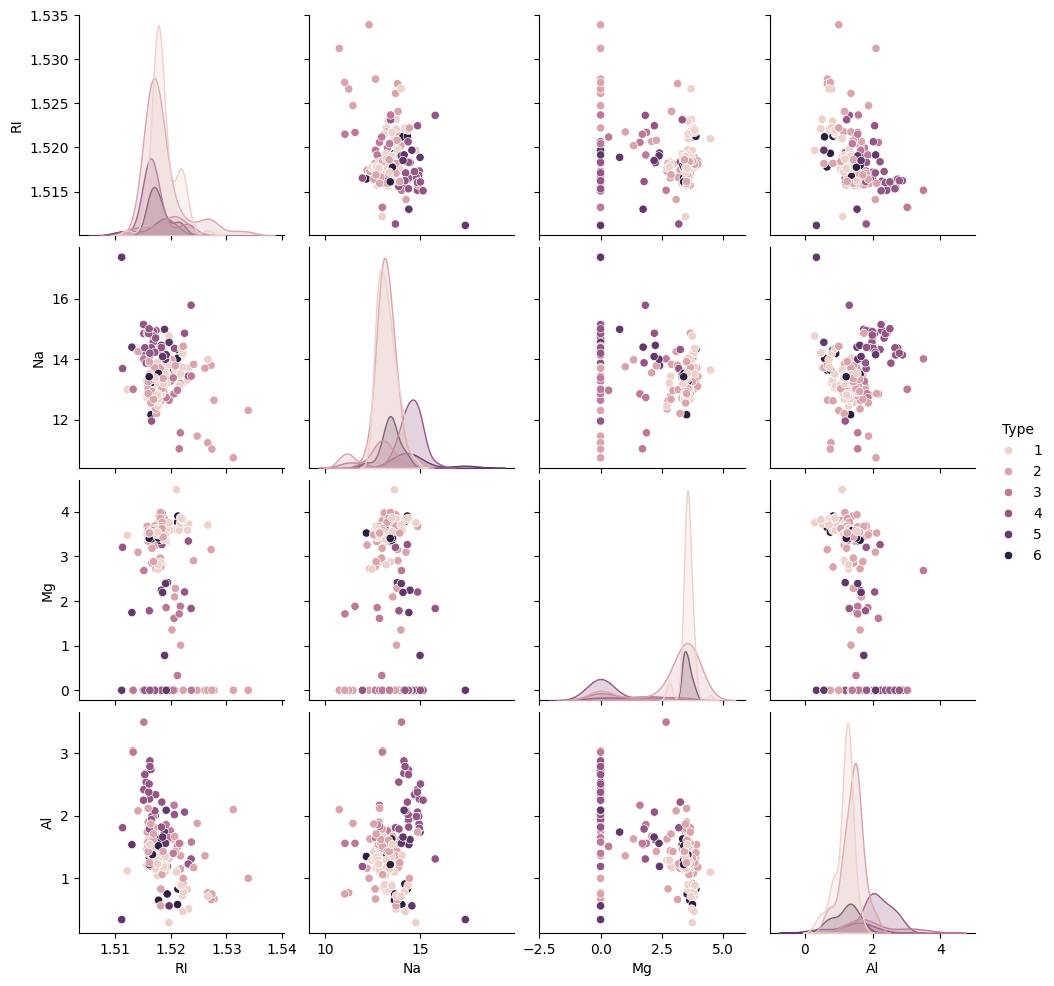

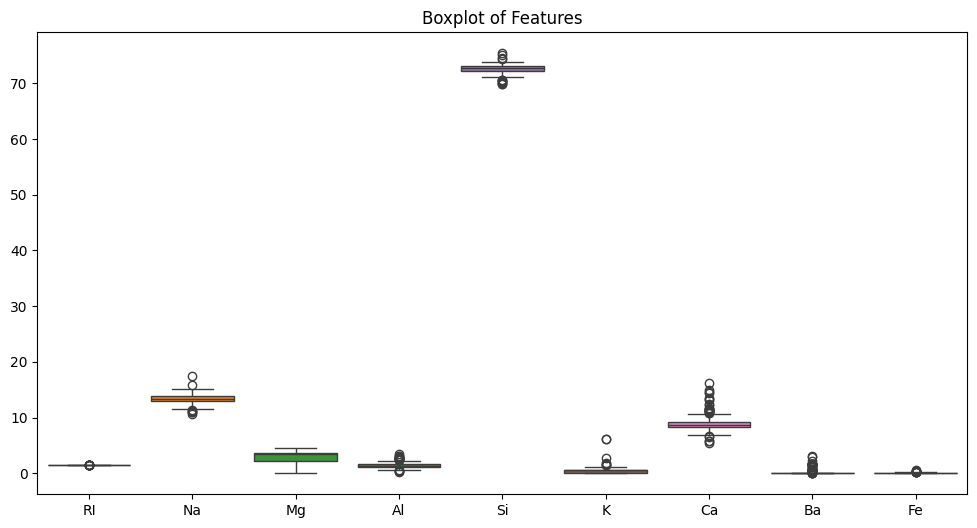

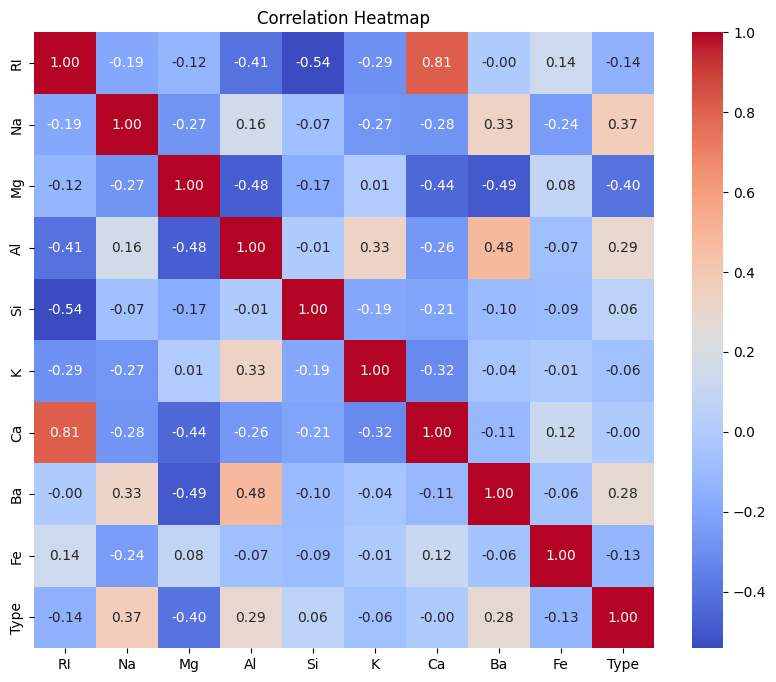


Random Forest Classification Report:
              precision    recall  f1-score   support

           1       0.78      0.86      0.82        21
           2       0.90      0.83      0.86        23
           3       0.75      0.75      0.75         4
           4       0.90      1.00      0.95         9
           5       0.75      1.00      0.86         3
           6       0.67      0.40      0.50         5

    accuracy                           0.83        65
   macro avg       0.79      0.81      0.79        65
weighted avg       0.83      0.83      0.83        65


Bagging Classification Report:
              precision    recall  f1-score   support

           1       0.78      0.86      0.82        21
           2       0.83      0.83      0.83        23
           3       0.75      0.75      0.75         4
           4       0.82      1.00      0.90         9
           5       0.67      0.67      0.67         3
           6       1.00      0.20      0.33         5

    acc

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.datasets import fetch_openml

# Step 1: Load the Glass dataset
glass = fetch_openml(name="glass", version=1, as_frame=True)
glass_data = glass.data
glass_target = glass.target   # This contains string labels like 'build wind float'

# Convert string labels to integer codes (1-7 as original)
le = LabelEncoder()
glass_target_encoded = le.fit_transform(glass_target) + 1   # +1 to get 1..7

# Add target as integer column
glass_data['Type'] = glass_target_encoded

# Step 2: Exploratory Data Analysis (EDA)
print("Dataset Info:")
print(glass_data.info())
print("\nSummary Statistics:")
print(glass_data.describe())
print("\nMissing Values:")
print(glass_data.isnull().sum())

# Step 3: Data Visualization
# Pair plot (might be slow; use a subset of features if needed)
sns.pairplot(glass_data, hue='Type', vars=glass_data.columns[:4], diag_kind='kde')
plt.show()

# Box plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=glass_data.drop(columns=['Type']))
plt.title('Boxplot of Features')
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
corr_matrix = glass_data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Step 4: Data Preprocessing
features = glass_data.drop(columns=['Type'])
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

labels = glass_data['Type']  # Already integer

# Step 5: Split the dataset
X_train, X_test, y_train, y_test = train_test_split(features_scaled, labels, test_size=0.3, random_state=42, stratify=labels)

# Step 6: Random Forest Model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Step 7: Bagging with Random Forest (using 'estimator' instead of 'base_estimator')
bagging_model = BaggingClassifier(estimator=RandomForestClassifier(random_state=42), n_estimators=50, random_state=42)
bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)
print("\nBagging Classification Report:")
print(classification_report(y_test, y_pred_bagging))

# Step 8: Boosting with AdaBoost (using 'estimator' instead of 'base_estimator')
boosting_model = AdaBoostClassifier(estimator=RandomForestClassifier(random_state=42), n_estimators=50, random_state=42)
boosting_model.fit(X_train, y_train)
y_pred_boosting = boosting_model.predict(X_test)
print("\nBoosting Classification Report:")
print(classification_report(y_test, y_pred_boosting))

# Optional: Accuracy comparison
print("\nAccuracy Comparison:")
print(f"Random Forest: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Bagging: {accuracy_score(y_test, y_pred_bagging):.4f}")
print(f"AdaBoost: {accuracy_score(y_test, y_pred_boosting):.4f}")